In [1]:
import numpy as np 
import pickle 
import pandas as pd 
from sklearn.metrics import confusion_matrix
import re
%matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')

In [2]:
outfig_dir = Path('talk_figs/simoncelli_group_07_30_2025/figs')
outfig_dir.mkdir(parents=True, exist_ok=True)


In [ ]:
def get_category_accuracies(predictions,labels,target):
    """
    Returns the accuracy for target category.
    """
    correct = 0
    total = 0
    for idx in range(len(labels)):
        label = labels[idx]
        if label==target:
            prediction = predictions[idx]
            if label==prediction:
                correct = correct+1
            total = total+1
    return correct/total


def format_model_str(path):
    path_str = str(path)
    task = ''
    eq_lmbda = ''
    if 'eq_lmbda' in path_str:
        eq_lmbda = re.search(r'eq_lmbda_([-\d.e]+)', path_str).group(1)
        if float(eq_lmbda) == 0:
            eq_lmbda = ''
        else:
            eq_lmbda = ' ' + eq_lmbda

    if 'dualtask' in path_str or 'equivariant' in path_str or (eq_lmbda != '' and float(eq_lmbda) != 0):
        task = 'equivariant'
    else:
        task = 'invariant'
    if '_dual_' in path_str:
        task = f"dual {task}"
    if 'audioset' in path_str:
        task = 'supervised audioset'
    if 'word' in path_str and not 'barlow' in path_str:
        task = 'supervised word'
    if 'word_speaker_audioset' in path_str:
        task = 'supervised multi-task'

    arch = 'kell2018'

    if "resnet" in path_str:
        arch = 'resnet' + re.search(r'resnet([-\d]+)', path_str).group(1)
    
    if 'byola' in path_str or 'config_linear' in path_str:
        if 'barlow' in path_str:
            arch = 'byol-a retrained'
        else:
            arch = 'byol-a o.g.'
            task = '' 
        
    aug_str = ''
    if 'resnet18' in path_str and not 'w_invar_aug' in path_str:
        aug_str = ' paired augmentations'
    if 'no_shared_fg_augments' in path_str:
        aug_str = ' unpaired augs'
        
    test_layer = path.stem.split("_")[-1] # is last name of stem 

    model_name = f"{arch} {task}{eq_lmbda}{aug_str}"
    if arch == 'byol-a o.g.':
        model_name = model_name.replace('byol-a o.g. ', 'byol-a o.g.')
        
    return model_name, arch, test_layer, eq_lmbda




## Get ESC 50 results for each model

In [44]:
path_to_esc_results = Path("esc_analysis")

all_model_results = list(path_to_esc_results.rglob("*barlow*kell2018*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("audioset_*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("resnet18_barlow*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("kell2018_barlow*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("kell2018*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("word_kell2018*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("config_linear*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("byola*/saved_vars*.pickle"))
# all_model_results

test_layers = [
                'preproc',
                'batchnorm0',
                'conv0',
                'relu0',
                'maxpool0',
                'batchnorm1',
                'conv1',
                'relu1',
                'maxpool1',
                'batchnorm2',
                'conv2',
                'relu2',
                'conv3',
                'relu3',
                'conv4',
                'relu4',
                'avgpool',
                'fullyconnected',
                'relufc',
                'dropout',
                ]
                
resnet18_layer_order = [
                'preproc',
                'conv1',
                'bn1',
                'relu1',
                'maxpool1',
                'layer1',
                'layer2',
                'layer3',
                'layer4',
                'avgpool',
            ]            
layer_order_dict = {l:i for i,l in enumerate(test_layers)}
df_list = []

for i, results_path in enumerate(all_model_results):
    path_str = str(results_path)

    if 'kell2018' in path_str and not results_path.parent.stem.startswith('kell2018'):
        if 'eq_lmbda' in path_str:
            # if 'fixed_loss' not in path_str:
            continue 
                
    if 'projects' in str(results_path):
        continue 
    results = pd.read_pickle(results_path)
    overall_acc = results['overall_acc']

    model_name, arch_class, test_layer, eq_lmbda = format_model_str(results_path)
    
    data = dict(model_name=model_name, arch_class=arch_class, test_layer=test_layer, eq_lmbda=eq_lmbda, overall_acc=overall_acc)
    if i == 0:
        category_list = np.array(list(results['target_to_category'].values()))
    # print(test_layer)
    
    # category_accuracies = np.stack(results['category_accuracies'], axis=0)
    # ## get category mean across splits 
    # means = category_accuracies.mean(0)
    # # get error (is standard deviation like in original script)
    # SEMs = category_accuracies.std(0)
    # # overall_acc 
    # overall_acc = results['overall_acc']

    df_list.append(data)

esc_50_df = pd.DataFrame.from_records(df_list)
esc_50_df['test_layer'] = esc_50_df['test_layer'].astype('str')

esc_50_df = esc_50_df.loc[esc_50_df['test_layer'].map({k: i for i, k in enumerate(test_layers)}) \
                .sort_values().index]

In [45]:
esc_50_df.test_layer.unique()

array(['preproc', 'batchnorm0', 'conv0', 'relu0', 'maxpool0',
       'batchnorm1', 'conv1', 'relu1', 'maxpool1', 'batchnorm2', 'conv2',
       'relu2', 'conv3', 'relu3', 'conv4', 'relu4', 'avgpool',
       'fullyconnected', 'relufc', 'dropout', 'layer1', 'layer2', 'bn1',
       'layer3', 'layer4', 'final'], dtype=object)

In [46]:
esc_50_df.model_name.unique()

array(['resnet18 equivariant 2e-01',
       'resnet18 equivariant 5e-01 paired augmentations',
       'resnet18 equivariant 1e-01', 'resnet18 equivariant 4e-01',
       'resnet18 equivariant 2e-01 paired augmentations',
       'resnet18 equivariant 3e-01', 'kell2018 equivariant 4e-01',
       'resnet18 equivariant 1e-02', 'kell2018 equivariant 2e-01',
       'kell2018 equivariant 3e-01', 'resnet18 equivariant 5e-01',
       'resnet18 equivariant 4e-01 paired augmentations',
       'kell2018 supervised multi-task',
       'kell2018 dual equivariant 5e-01', 'kell2018 dual invariant',
       'kell2018 equivariant 1e-01',
       'resnet18 equivariant 1e-01 paired augmentations',
       'resnet18 equivariant 3e-01 paired augmentations',
       'resnet18 equivariant 1', 'resnet18 invariant',
       'kell2018 equivariant 8e-01', 'kell2018 equivariant 5e-01',
       'kell2018 supervised word', 'kell2018 supervised audioset',
       'kell2018 invariant', 'kell2018 dual invariant unpaired augs',

## Get word task results 

In [70]:
def format_model_str_word_task(path):
    path_str = str(path)
    eq_lmbda = ''
    if 'eq_lmbda' in path_str:
        eq_lmbda = re.search(r'eq_lmbda_([-\d.e]+)', path_str).group(1)
        if float(eq_lmbda) == 0:
            eq_lmbda = ''
        else:
            eq_lmbda = ' ' + eq_lmbda

    task = ''
    if 'dualtask' in path_str or 'equivariant' in path_str or (eq_lmbda != '' and float(eq_lmbda) != 0):
        task = 'equivariant'
    else:
        task = 'invariant'
    if '_dual_' in path_str:
        task = f"dual {task}"
    if 'audioset' in path_str:
        task = 'supervised audioset'
    elif 'word' in path_str and not 'barlow' in path_str:
        task = 'supervised word'
    if 'word_speaker_audioset' in path_str:
        task = 'supervised multi-task'
    arch = 'kell2018'

    if "resnet" in path_str:
        arch = 'resnet' + re.search(r'resnet([-\d]+)', path_str).group(1)

    
    if 'byola' in path_str or 'config_linear' in path_str:
        if 'barlow' in path_str:
            arch = 'byol-a retrained'
        else:
            arch = 'byol-a o.g.'
            task = '' 

    test_layer = path_str.split('task_')[-1].split('_')[0]
    
    aug_str = ''
    if 'resnet18' in path_str and not 'w_invar_aug' in path_str:
        aug_str = ' paired augmentations'
    if 'no_shared_fg_augments' in path_str:
        aug_str = ' unpaired augs'

    model_name = f"{arch} {task}{eq_lmbda}{aug_str}"
    if arch == 'byol-a o.g.':
        model_name = model_name.replace('byol-a o.g. ', 'byol-a o.g.')
    return model_name, arch, test_layer, eq_lmbda

In [71]:
path_to_word_results = Path("eval_jsin_results")
kell2018_word_results = list(path_to_word_results.rglob("*kell2018*.pkl"))
kell2018_word_results = [path for path in kell2018_word_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands']])]

# kell2018_word_results = list(path_to_word_results.rglob("*kell2018*.pkl"))
# kell2018_word_results = [path for path in kell2018_word_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands']])]

resnet18_word_results = list(path_to_word_results.rglob("resnet18*.pkl"))
resnet18_word_results = [path for path in resnet18_word_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands']])]

byola_results =  list(path_to_word_results.rglob("config_linear*.pkl"))
byola_results = [path for path in byola_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands', '0.01']])]

byola_results_new =  list(path_to_word_results.rglob("byola*.pkl"))
byola_results += [path for path in byola_results_new if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands', '0.01']])]

all_word_task_results = kell2018_word_results + resnet18_word_results + byola_results

df_list = []

for i, results_path in enumerate(all_word_task_results):
    path_str = str(results_path)
    # if results_path.name.startswith('audioset'):
    #     print(path_str)

    if 'kell2018' in path_str and not results_path.name.startswith('kell2018'):
        if 'eq_lmbda' in path_str:

            # if 'fixed_loss' not in path_str:
            continue 
    if 'kell2018' in path_str and not 'w_dropout_center_eval_words' in path_str:

        continue
        
    if not any([layer in str(results_path) for layer in test_layers + resnet18_layer_order]):

        continue 

    results = pd.read_pickle(results_path)
    # break 

    model_name, arch_class, test_layer, eq_lmbda = format_model_str_word_task(results_path)
    
    data = dict(model_name=model_name, arch_class=arch_class, test_layer=test_layer, eq_lmbda=eq_lmbda)
    data = {**data, **results}

    # print(test_layer)

    # category_accuracies = np.stack(results['category_accuracies'], axis=0)
    # ## get category mean across splits 
    # means = category_accuracies.mean(0)
    # # get error (is standard deviation like in original script)
    # SEMs = category_accuracies.std(0)
    # # overall_acc 
    # overall_acc = results['overall_acc']

    df_list.append(data)

word_df = pd.DataFrame.from_records(df_list)
word_df['test_layer'] = word_df['test_layer'].astype('str')
word_df['task'] = '800-word classification'

In [72]:
word_df.model_name.unique()

array(['kell2018 dual invariant unpaired augs',
       'kell2018 dual equivariant 1e-02', 'kell2018 supervised word',
       'kell2018 equivariant 1e-01', 'kell2018 equivariant 4e-01',
       'kell2018 supervised audioset', 'kell2018 equivariant 3e-01',
       'kell2018 supervised multi-task', 'kell2018 equivariant 5e-01',
       'kell2018 equivariant 2e-01', 'kell2018 invariant',
       'kell2018 dual equivariant 5e-01',
       'kell2018 dual equivariant 1e-01', 'kell2018 dual invariant',
       'resnet18 equivariant 5e-01', 'resnet18 equivariant 1e-01',
       'resnet18 equivariant 3e-01',
       'resnet18 equivariant 3e-01 paired augmentations',
       'resnet18 invariant', 'resnet18 equivariant 4e-01',
       'resnet18 equivariant 2e-01', 'resnet18 equivariant 1e-02',
       'resnet18 equivariant 1', 'byol-a o.g.',
       'byol-a retrained invariant'], dtype=object)

In [73]:
df = pd.concat([word_df, esc_50_df], axis=0, ignore_index=True)
df.head()

,model_name,arch_class,test_layer,eq_lmbda,word_top1_mean,word_top1_sem,speaker_top1_mean,speaker_top1_sem,word_top5_mean,word_top5_sem,speaker_top5_mean,speaker_top5_sem,task,overall_acc
0,kell2018 dual invariant unpaired augs,kell2018,relu4,,0.756403,0.001014,0.999490,0.000049,0.989996,0.000270,1.000000,2.942227e-10,800-word classification,NaN
1,kell2018 dual equivariant 1e-02,kell2018,relu4,1e-02,0.734701,0.001058,0.999429,0.000051,0.988358,0.000291,1.000000,2.942227e-10,800-word classification,NaN
2,kell2018 supervised word,kell2018,relu1,,0.726751,0.001035,0.998746,0.000078,0.972820,0.000693,0.999921,1.837652e-05,800-word classification,NaN
3,kell2018 equivariant 1e-01,kell2018,relu1,1e-01,0.612794,0.001162,0.998705,0.000078,0.959728,0.000822,0.999882,2.401590e-05,800-word classification,NaN
4,kell2018 equivariant 1e-01,kell2018,relu4,1e-01,0.809655,0.000949,0.998945,0.000069,0.994027,0.000184,1.000000,2.942227e-10,800-word classification,NaN


In [58]:
word_df

,model_name,arch_class,test_layer,eq_lmbda,word_top1_mean,word_top1_sem,speaker_top1_mean,speaker_top1_sem,word_top5_mean,word_top5_sem,speaker_top5_mean,speaker_top5_sem,task
0,kell2018 equivariant 5e-01,kell2018,relu0,5e-01,0.184229,0.001017,0.983177,0.000388,0.827061,0.006277,0.995555,2.107547e-04,800-word classification
1,kell2018 dual invariant unpaired augs,kell2018,relu4,,0.756403,0.001014,0.999490,0.000049,0.989996,0.000270,1.000000,2.942227e-10,800-word classification
2,kell2018 dual equivariant 1e-02,kell2018,relu4,1e-02,0.734701,0.001058,0.999429,0.000051,0.988358,0.000291,1.000000,2.942227e-10,800-word classification
3,kell2018 supervised word,kell2018,relu1,,0.726751,0.001035,0.998746,0.000078,0.972820,0.000693,0.999921,1.837652e-05,800-word classification
4,kell2018 equivariant 3e-01,kell2018,relu2,3e-01,0.811457,0.000937,0.999703,0.000035,0.993793,0.000189,0.999996,4.343880e-06,800-word classification
...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,resnet18 equivariant 2e-01,resnet18,layer2,2e-01,0.526651,0.000835,NaN,NaN,0.938880,0.000421,NaN,NaN,800-word classification
74,resnet18 equivariant 3e-01,resnet18,layer2,3e-01,0.518387,0.000839,NaN,NaN,0.938418,0.000431,NaN,NaN,800-word classification
75,byol-a o.g.,byol-a o.g.,final,,0.159087,0.000797,0.587997,0.005622,0.885378,0.001565,0.923719,1.477826e-03,800-word classification
76,byol-a o.g.,byol-a o.g.,avgpool,,0.152517,0.000613,NaN,NaN,0.880565,0.000624,NaN,NaN,800-word classification


# Get SpeechCommands results

In [41]:
def format_model_str_sc_task(path):
    path_str = str(path)
    eq_lmbda = ''
    if 'eq_lmbda' in path_str:
        eq_lmbda = re.search(r'eq_lmbda_([-\d.e]+)', path_str).group(1)
        if float(eq_lmbda) == 0:
            eq_lmbda = ''
        else:
            eq_lmbda = ' ' + eq_lmbda

    task = ''
    if 'dualtask' in path_str or 'equivariant' in path_str or (eq_lmbda != '' and float(eq_lmbda) != 0):
        task = 'equivariant'
    else:
        task = 'invariant'
    if '_dual_' in path_str:
        task = f"dual {task}"
    if 'audioset' in path_str:
        task = 'supervised audioset'
    if 'word' in path_str and not 'barlow' in path_str:
        task = 'supervised word'
    if 'word_speaker_audioset' in path_str:
        task = 'supervised multi-task'
        
    arch = 'kell2018'

    if "resnet" in path_str:
        arch = 'resnet' + re.search(r'resnet([-\d]+)', path_str).group(1)
    
    if 'config' in path_str:
        arch = 'byol-a'
        task = ''
        

    test_layer = path_str.split('AdamW_')[-1].split('_')[0]
    
    aug_str = ''
    if 'resnet18' in path_str and not 'w_invar_aug' in path_str:
        aug_str = ' paired augmentations'
    model_name = f"{arch} {task}{eq_lmbda}{aug_str}"
    if arch == 'byol-a':
        model_name = model_name.replace('byol-a ', 'byol-a')
    return model_name, arch, test_layer, eq_lmbda

In [42]:
path_to_speech_commands_results = Path("eval_jsin_results/linear_eval_speech_commands")
kell2018_speech_commands_results = list(path_to_speech_commands_results.rglob("*kell2018*.pkl"))
kell2018_speech_commands_results = [path for path in kell2018_speech_commands_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'mmcr']])]

resnet18_speech_commands_results = list(path_to_speech_commands_results.rglob("resnet18*.pkl"))
resnet18_speech_commands_results = [path for path in resnet18_speech_commands_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop']])]

byola_results =  list(path_to_speech_commands_results.rglob("config_*.pkl"))

all_speech_commands_task_results = kell2018_speech_commands_results + resnet18_speech_commands_results + byola_results

df_list = []

for i, results_path in enumerate(all_speech_commands_task_results):
    path_str = str(results_path)
    # if results_path.name.startswith('audioset'):
    #     print(path_str)

    if 'kell2018' in path_str and not results_path.name.startswith('kell2018'):
        if 'eq_lmbda' in path_str:

            # if 'fixed_loss' not in path_str:
            continue 
    # if 'kell2018' in path_str and not 'w_dropout_center_eval_words' in path_str:

    #     continue
        
    if not any([layer in str(results_path) for layer in test_layers + resnet18_layer_order + ['final']]):

        continue 

    results = pd.read_pickle(results_path)
    # break 

    model_name, arch_class, test_layer, eq_lmbda = format_model_str_sc_task(results_path)
    
    data = dict(model_name=model_name, arch_class=arch_class, test_layer=test_layer, eq_lmbda=eq_lmbda)
    data = {**data, **results}

    # print(test_layer)

    # category_accuracies = np.stack(results['category_accuracies'], axis=0)
    # ## get category mean across splits 
    # means = category_accuracies.mean(0)
    # # get error (is standard deviation like in original script)
    # SEMs = category_accuracies.std(0)
    # # overall_acc 
    # overall_acc = results['overall_acc']

    df_list.append(data)

speech_commands_df = pd.DataFrame.from_records(df_list)
speech_commands_df['test_layer'] = speech_commands_df['test_layer'].astype('str')
speech_commands_df['task'] = '20-word classification'

In [43]:
## Compare word rec performance 

all_word_eval_df = pd.concat([word_df, speech_commands_df], axis=0, ignore_index=True)


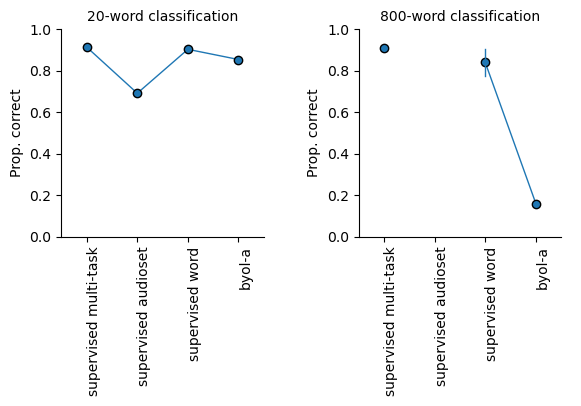

In [44]:
hue_order = [ 
              'kell2018 supervised multi-task',
              'kell2018 supervised audioset',
              'kell2018 supervised word',
                'byol-a',
              ]

task_order = [
              '20-word classification',
              '800-word classification',
              ]

model_name_list = [name.replace('kell2018 ', '') for name in hue_order]
test_layers = ['relu4', 'final']

to_plot  = all_word_eval_df[all_word_eval_df.model_name.str.contains('supervised|byol') & all_word_eval_df.test_layer.isin(test_layers)].copy()

# to_plot = to_plot.sort_values('word_top1_mean', ascending=False).drop_duplicates('model_name')
models_for_plot = hue_order
to_plot = to_plot[to_plot.model_name.isin(models_for_plot)]
g = sns.catplot(data=to_plot,
                kind='point',
                order=models_for_plot,
                x='model_name',
                y='word_top1_mean',
                col ='task',
                col_order=task_order,
                # col='arch_class',
                # hue="model_name",
                # hue_order=hue_order,
                # height=4,
                sharey=False,
                # ax = axs[0],
                height=3,
                mec='k',
                mew=1,
                lw=1, ms=6
                )

g.set_titles("{col_name}")
g.set_xticklabels(labels=model_name_list, rotation=90, ha='right', rotation_mode='anchor')
g.set(ylim=(0, 1),  ylabel='Prop. correct', xlabel='')
sns.despine()



# g.set_xticklabels(labels=['kell2018 supervised word', 'kell2018 supervised multi-task', 'byol-a '], rotation=45, ha='right', rotation_mode='anchor')
# g.set(ylim=(0, 1.05), title="Word recognition", ylabel='Prop. correct', xlabel='Model')
# sns.despine()

# plt.subplots_adjust(wspace=0.5)
# plt.savefig(outfig_dir/'byola_vs_sup.png', transparent=True,dpi=500,  bbox_inches='tight')
# plt.savefig(outfig_dir/'byola_vs_sup_word_task.png', transparent=True,dpi=500,  bbox_inches='tight')



# Plot ESC 50 results

/tmp/ipykernel_1068488/1910819552.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=model_name_list, rotation=90, ha='right', rotation_mode='anchor')
/tmp/ipykernel_1068488/1910819552.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=model_name_list, rotation=90, ha='right', rotation_mode='anchor')
/tmp/ipykernel_1068488/1910819552.py:67: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  word_to_plot = to_plot[(~df.word_top1_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)
/tmp/ipykernel_1068488/1910819552.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=model_name_list, rotation=90, ha='right', rotation_mode='anchor'

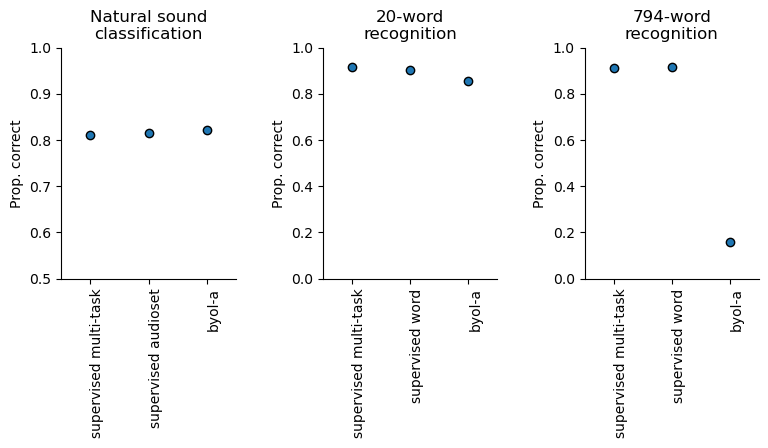

In [45]:
model_order = ['kell2018 supervised multi-task',
              'kell2018 supervised word',
              'kell2018 supervised audioset',
              'byol-a']

fig, axs = plt.subplots(1,3, figsize=(9,3))

to_plot  = df[df.model_name.str.contains('supervised|byol')].copy()


esc_50_to_plot = to_plot.sort_values('overall_acc', ascending=False).drop_duplicates('model_name')
model_order = ['kell2018 supervised multi-task',
            #   'kell2018 supervised word',
              'kell2018 supervised audioset',
              'byol-a']
model_name_list = [name.replace('kell2018 ', '') for name in model_order]

esc_50_to_plot = esc_50_to_plot[esc_50_to_plot.model_name.isin(model_order)]
g = sns.pointplot(data=esc_50_to_plot,
                order=model_order,
                x='model_name',
                y='overall_acc',
                # col='arch_class',
                # hue="model_name",
                # hue_order=hue_order,
                # height=4,
                ax = axs[0],
                mec='k',
                mew=1,
                lw=0,
                ms=6
                )

g.set_xticklabels(labels=model_name_list, rotation=90, ha='right', rotation_mode='anchor')
g.set(ylim=(0.5, 1), title="Natural sound\nclassification", ylabel='Prop. correct', xlabel='')
sns.despine()


sc_to_plot = speech_commands_df[(~speech_commands_df.word_top1_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)

sc_to_plot = sc_to_plot.sort_values('word_top1_mean', ascending=False).drop_duplicates('model_name')
model_order = ['kell2018 supervised multi-task',
              'kell2018 supervised word',
            #   'kell2018 supervised audioset',
              'byol-a']
model_name_list = [name.replace('kell2018 ', '') for name in model_order]

sc_to_plot = sc_to_plot[sc_to_plot.model_name.isin(model_order)]
g = sns.pointplot(data=sc_to_plot,
                order=model_order,
                x='model_name',
                y='word_top1_mean',
                # col='arch_class',
                # hue="model_name",
                # hue_order=hue_order,
                # height=4,
                ax = axs[1],
                mec='k',
                mew=1,
                lw=0,
                ms=6
                )

g.set_xticklabels(labels=model_name_list, rotation=90, ha='right', rotation_mode='anchor')
g.set(ylim=(0, 1), title="20-word\nrecognition", ylabel='Prop. correct', xlabel='')

word_to_plot = to_plot[(~df.word_top1_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)

word_to_plot = word_to_plot.sort_values('word_top1_mean', ascending=False).drop_duplicates('model_name')
model_order = ['kell2018 supervised multi-task',
              'kell2018 supervised word',
            #   'kell2018 supervised audioset',
              'byol-a']
model_name_list = [name.replace('kell2018 ', '') for name in model_order]

word_to_plot = word_to_plot[word_to_plot.model_name.isin(model_order)]
g = sns.pointplot(data=word_to_plot,
                order=model_order,
                x='model_name',
                y='word_top1_mean',
                # col='arch_class',
                # hue="model_name",
                # hue_order=hue_order,
                # height=4,
                ax = axs[2],
                mec='k',
                mew=1,
                lw=0,
                ms=6
                )

g.set_xticklabels(labels=model_name_list, rotation=90, ha='right', rotation_mode='anchor')
g.set(ylim=(0, 1), title="794-word\nrecognition", ylabel='Prop. correct', xlabel='')
sns.despine()

plt.subplots_adjust(wspace=0.5)
plt.savefig(outfig_dir/'byola_vs_sup.png', transparent=True,dpi=500,  bbox_inches='tight')



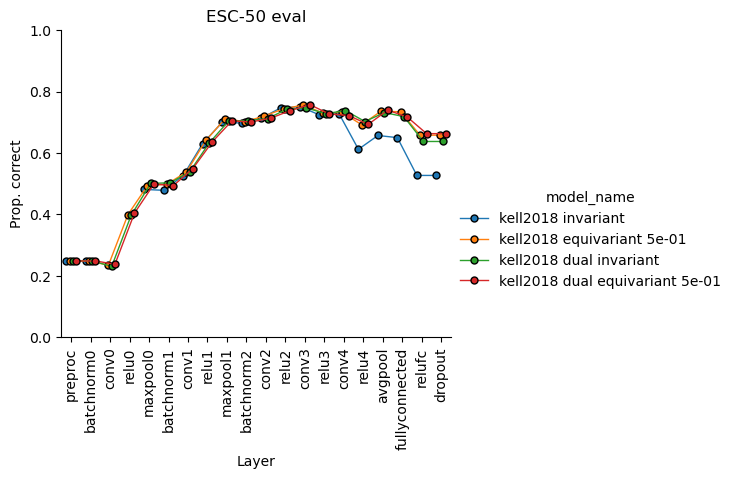

In [46]:
hue_order = [
            #   'kell2018 supervised word',
              'kell2018 invariant',
            #   'kell2018 equivariant 1e-01',
            #   'kell2018 equivariant 2e-01',
            #   'kell2018 equivariant 3e-01',
            #   'kell2018 equivariant 4e-01',
              'kell2018 equivariant 5e-01',
            #   'kell2018 equivariant 8e-01',
              'kell2018 dual invariant',
              'kell2018 dual equivariant 5e-01',
            #   'kell2018 supervised audioset',
            #   'kell2018 supervised multi-task',
              ]
test_layers = [
                'preproc',
                'batchnorm0',
                'conv0',
                'relu0',
                'maxpool0',
                'batchnorm1',
                'conv1',
                'relu1',
                'maxpool1',
                'batchnorm2',
                'conv2',
                'relu2',
                'conv3',
                'relu3',
                'conv4',
                'relu4',
                'avgpool',
                'fullyconnected',
                'relufc',
                'dropout',
                ]

g = sns.catplot(data=df[df.arch_class == 'kell2018'],
                order=test_layers,
                kind='point',
                x='test_layer',
                y='overall_acc',
                col='arch_class',
                hue="model_name",
                hue_order=hue_order,
                dodge=0.5,
                height=4,
                aspect=1.25,
                lw=1,
                mec='k',
                mew=1,
                ms=5)
g.set_xticklabels(rotation=90)
g.set(ylim=(0, 1), ylabel='Prop. correct', xlabel='Layer', title='ESC-50 eval')

In [47]:
esc_50_to_plot = df[(df.arch_class == 'kell2018') & (~df.overall_acc.isna()) & (df.test_layer.str.contains('relu'))]
esc_50_to_plot[esc_50_to_plot.eq_lmbda == ' 5e-01'].groupby(['test_layer', 'model_name']).overall_acc.max()

test_layer  model_name                     
relu0       kell2018 dual equivariant 5e-01    0.4040
            kell2018 equivariant 5e-01         0.3995
relu1       kell2018 dual equivariant 5e-01    0.6365
            kell2018 equivariant 5e-01         0.6410
relu2       kell2018 dual equivariant 5e-01    0.7380
            kell2018 equivariant 5e-01         0.7440
relu3       kell2018 dual equivariant 5e-01    0.7270
            kell2018 equivariant 5e-01         0.7305
relu4       kell2018 dual equivariant 5e-01    0.6930
            kell2018 equivariant 5e-01         0.6920
relufc      kell2018 dual equivariant 5e-01    0.6630
            kell2018 equivariant 5e-01         0.6580
Name: overall_acc, dtype: float64

/tmp/ipykernel_3372226/290534932.py:112: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=model_names_for_x, rotation=90, ) #ha='right', rotation_mode='anchor')


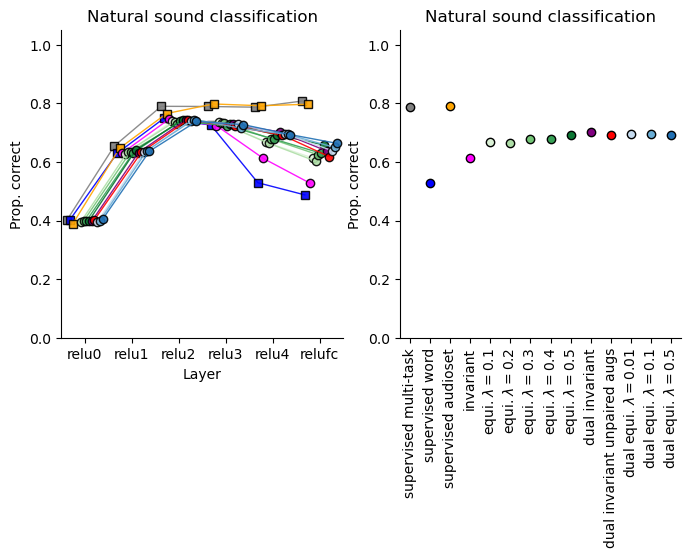

In [19]:
hue_order = [
              'kell2018 supervised multi-task',
              'kell2018 supervised word',
              'kell2018 supervised audioset',
              'kell2018 invariant',
              'kell2018 equivariant 1e-01',
              'kell2018 equivariant 2e-01',
              'kell2018 equivariant 3e-01',
              'kell2018 equivariant 4e-01',
              'kell2018 equivariant 5e-01',
              'kell2018 dual invariant',
              "kell2018 dual invariant unpaired augs",
              'kell2018 dual equivariant 1e-02',
              'kell2018 dual equivariant 1e-01',
              'kell2018 dual equivariant 5e-01',
            #   'kell2018 equivariant 8e-01',
              ]

marker_palette = ['s' if 'supervised' in model else 'o' for model in hue_order]
             
              

# set palette 
hue_dict = {}
hue_dict['kell2018 supervised word'] = 'blue'
hue_dict['kell2018 supervised audioset'] = 'orange' 
hue_dict['kell2018 supervised multi-task'] = 'grey'
hue_dict['kell2018 invariant'] = 'magenta'
hue_dict['kell2018 dual invariant'] = 'purple'
hue_dict['kell2018 dual invariant unpaired augs'] = 'red'
# hue_dict['kell2018 dual equivariant 5e-01'] = 'olive'

model_names_for_x = []

for name in hue_order:
    name = name.replace('kell2018 ', '')
    if "e-0" in name:
        lmbda = name.split(' ')[-1]
        if 'dual' in name:
            name = f"dual equi. $\\lambda=${float(lmbda)}"
        else:
            name = f"equi. $\\lambda=${float(lmbda)}"

    model_names_for_x.append(name)



layer_order = [
            'relu0', 'relu1', 'relu2', 'relu3', 'relu4', 'relufc'
]

eq_model_list = hue_order[4:9]
equi_palette = sns.color_palette("Greens", n_colors=len(eq_model_list)) 
equi_color_dict = dict(zip(eq_model_list, equi_palette))

dual_equi_model_list = hue_order[-3:]
dual_equi_palette = sns.color_palette("Blues", n_colors=len(dual_equi_model_list)) 
dual_equi_color_dict = dict(zip(dual_equi_model_list, dual_equi_palette))

hue_dict = {**hue_dict, **equi_color_dict, **dual_equi_color_dict}

esc_50_to_plot = df[(df.arch_class == 'kell2018') & (~df.overall_acc.isna()) & (df.test_layer.str.contains('relu'))]

# esc_50_to_plot = esc_50_to_plot.sort_values('overall_acc', ascending=False).drop_duplicates('model_name')

# esc_50_to_plot = esc_50_to_plot.loc[esc_50_to_plot['test_layer'].map({k: i for i, k in enumerate(kell2018_layer_order)}) \
#                 .sort_values().index]

fig, axes = plt.subplots(1,2,figsize=(8,4))

g = sns.pointplot(data=esc_50_to_plot, 
                order=layer_order,
                hue='model_name', y='overall_acc', #col='arch_class',
                x="test_layer",
                palette=hue_dict,
                hue_order=hue_order,
                alpha=0.9,
                dodge=0.75,
                ax = axes[0],
                legend=False,
                markers=marker_palette,
            # ls='',
                mec='k',
                mew=1,
                lw=1, ms=6
                #  height=4, 
                 )
g.set(ylim=(0, 1.05), title="Natural sound classification", ylabel='Prop. correct', xlabel='Layer')

test_layers = ['relu4', 'final', 'avgpool']

to_plot = esc_50_to_plot[(esc_50_to_plot.model_name.isin(hue_order)) & esc_50_to_plot.test_layer.isin(test_layers)]
to_plot = to_plot[~((to_plot.model_name.str.contains('kell')) & to_plot.test_layer.str.contains('avgpool'))]
# models_for_esc = ['kell2018 supervised word', 'kell2018 supervised multi-task', 'byol-a ']
# esc_50_to_plot = esc_50_to_plot[esc_50_to_plot.model_name.str.contains('kell2018|byola')]
g = sns.pointplot(data=to_plot,
                order=hue_order,
                x='model_name',
                y='overall_acc',
                # col='arch_class',
                hue="model_name",
                palette=hue_dict,
                # markers=marker_palette,
                # hue_order=hue_order,
                # height=4,
                ax = axes[1],
                mec='k',
                mew=1,
                lw=1, ms=6
                )

g.set_xticklabels(labels=model_names_for_x, rotation=90, ) #ha='right', rotation_mode='anchor')
g.set(ylim=(0., 1.05), title="Natural sound classification", ylabel='Prop. correct', xlabel='')
sns.despine()


/tmp/ipykernel_3372226/1740485697.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=model_names_for_x, rotation=90, ) #ha='right', rotation_mode='anchor')
/tmp/ipykernel_3372226/1740485697.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=model_names_for_x, rotation=90, ) #ha='right', rotation_mode='anchor')


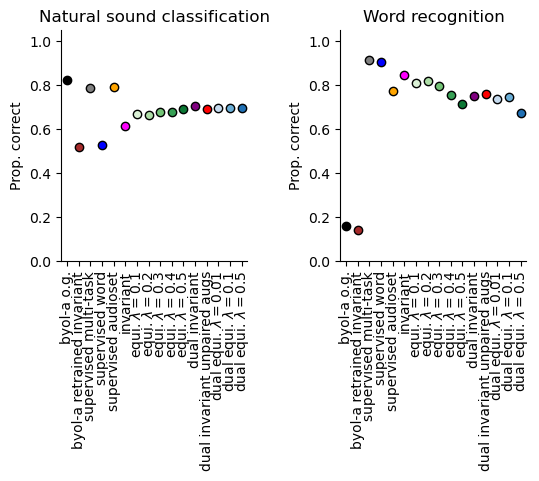

In [74]:
hue_order = [ 
              'byol-a o.g.', 
              'byol-a retrained invariant',
              'kell2018 supervised multi-task',
              'kell2018 supervised word',
              'kell2018 supervised audioset',
              'kell2018 invariant',
              'kell2018 equivariant 1e-01',
              'kell2018 equivariant 2e-01',
              'kell2018 equivariant 3e-01',
              'kell2018 equivariant 4e-01',
              'kell2018 equivariant 5e-01',
              'kell2018 dual invariant',
              "kell2018 dual invariant unpaired augs",
              'kell2018 dual equivariant 1e-02',
              'kell2018 dual equivariant 1e-01',
              'kell2018 dual equivariant 5e-01',
            #   'kell2018 equivariant 8e-01',
              ]

marker_palette = ['s' if 'supervised' in model else 'o' for model in hue_order]
             
              

# set palette 
hue_dict = {}
hue_dict['byol-a o.g.'] = 'black'
hue_dict['byol-a retrained invariant'] = 'brown'
hue_dict['kell2018 supervised word'] = 'blue'
hue_dict['kell2018 supervised audioset'] = 'orange' 
hue_dict['kell2018 supervised multi-task'] = 'grey'
hue_dict['kell2018 invariant'] = 'magenta'
hue_dict['kell2018 dual invariant'] = 'purple'
hue_dict['kell2018 dual invariant unpaired augs'] = 'red'

# hue_dict['kell2018 dual equivariant 5e-01'] = 'olive'

model_names_for_x = []

for name in hue_order:
    name = name.replace('kell2018 ', '')
    if "e-0" in name:
        lmbda = name.split(' ')[-1]
        if 'dual' in name:
            name = f"dual equi. $\\lambda=${float(lmbda)}"
        else:
            name = f"equi. $\\lambda=${float(lmbda)}"

    model_names_for_x.append(name)



layer_order = [
            'relu0', 'relu1', 'relu2', 'relu3', 'relu4', 'relufc'
]

eq_model_list = hue_order[6:11]
equi_palette = sns.color_palette("Greens", n_colors=len(eq_model_list)) 
equi_color_dict = dict(zip(eq_model_list, equi_palette))

dual_equi_model_list = hue_order[-3:]
dual_equi_palette = sns.color_palette("Blues", n_colors=len(dual_equi_model_list)) 
dual_equi_color_dict = dict(zip(dual_equi_model_list, dual_equi_palette))

hue_dict = {**hue_dict, **equi_color_dict, **dual_equi_color_dict}

fig, axs = plt.subplots(1,2, figsize=(6,3))
to_plot  = df[df.model_name.str.contains('kell2018|byol')].copy()

test_layers = ['relu4', 'final']

to_plot = to_plot[(to_plot.model_name.isin(hue_order)) & to_plot.test_layer.isin(test_layers)]
# to_plot = to_plot[~((to_plot.model_name.str.contains('kell')) & to_plot.test_layer.str.contains('avgpool'))]
# models_for_esc = ['kell2018 supervised word', 'kell2018 supervised multi-task', 'byol-a ']
# esc_50_to_plot = esc_50_to_plot[esc_50_to_plot.model_name.str.contains('kell2018|byola')]
g = sns.pointplot(data=to_plot,
                order=hue_order,
                x='model_name',
                y='overall_acc',
                # col='arch_class',
                hue="model_name",
                palette=hue_dict,

                # hue_order=hue_order,
                # height=4,
                ax = axs[0],
                mec='k',
                mew=1,
                lw=1, ms=6
                )

g.set_xticklabels(labels=model_names_for_x, rotation=90, ) #ha='right', rotation_mode='anchor')
g.set(ylim=(0., 1.05), title="Natural sound classification", ylabel='Prop. correct', xlabel='')
sns.despine()


# word_to_plot = to_plot[(~to_plot.word_top1_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)

word_to_plot = to_plot.drop_duplicates('model_name')

g = sns.pointplot(data=word_to_plot,
                order=hue_order,
                x='model_name',
                y='word_top1_mean',
                # col='arch_class',
                hue="model_name",
                palette=hue_dict,

                # hue_order=hue_order,
                # height=4,
                ax = axs[1],
                mec='k',
                mew=1,
                lw=1, ms=6
                )

g.set_xticklabels(labels=model_names_for_x, rotation=90, ) #ha='right', rotation_mode='anchor')
g.set(ylim=(0, 1.05), title="Word recognition", ylabel='Prop. correct', xlabel='')
sns.despine()

plt.subplots_adjust(wspace=0.5)

# speaker_to_plot = to_plot[(~to_plot.speaker_top1_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)
# speaker_to_plot = speaker_to_plot.sort_values('speaker_top1_mean', ascending=False).drop_duplicates('model_name')

# g = sns.pointplot(data=to_plot,
#                 order=hue_order,
#                 hue="model_name",
#                 palette=hue_dict,
#                 y='speaker_top1_mean', 
#                 x="model_name", 
#                 ax=axs[2],
#                 # ls='',
#                 # markers=marker_palette,
#                 mec='k',
#                 mew=1,
#                 lw=1, ms=6
#                 )
# # g.set_xticklabels(labels=model_names_for_x, rotation=90)
# g.set(ylim=(0, 1.05), title="Speaker recognition", ylabel='Prop. correct', xlabel='')
# g.set_xticklabels(labels=model_names_for_x, rotation=90,)# ) #ha='right', rotation_mode='anchor')

# # handles, labels = g.get_legend_handles_labels()
# labels = [label.replace('kell2018 ', '') for label in labels]
# Create a new legend with customized labels and title
# g.legend(handles, labels, frameon=False, fontsize=8)

sns.despine()


# plt.savefig(outfig_dir/'all_models_speech_esc_relu4.png', transparent=True,dpi=500,  bbox_inches='tight')



In [69]:
to_plot

,model_name,arch_class,test_layer,eq_lmbda,word_top1_mean,word_top1_sem,speaker_top1_mean,speaker_top1_sem,word_top5_mean,word_top5_sem,speaker_top5_mean,speaker_top5_sem,task,overall_acc
1,kell2018 dual invariant unpaired augs,kell2018,relu4,,0.756403,0.001014,0.999490,0.000049,0.989996,0.000270,1.000000,2.942227e-10,800-word classification,NaN
2,kell2018 dual equivariant 1e-02,kell2018,relu4,1e-02,0.734701,0.001058,0.999429,0.000051,0.988358,0.000291,1.000000,2.942227e-10,800-word classification,NaN
10,kell2018 equivariant 1e-01,kell2018,relu4,1e-01,0.809655,0.000949,0.998945,0.000069,0.994027,0.000184,1.000000,2.942227e-10,800-word classification,NaN
16,kell2018 supervised word,kell2018,relu4,,0.773257,0.001632,0.999716,0.000035,0.995595,0.000161,1.000000,2.942227e-10,800-word classification,NaN
19,kell2018 supervised multi-task,kell2018,relu4,,0.911241,0.000858,0.999847,0.000025,0.989853,0.000481,0.999982,8.735446e-06,800-word classification,NaN
21,kell2018 equivariant 5e-01,kell2018,relu4,5e-01,0.712199,0.001022,0.998736,0.000076,0.987203,0.000329,1.000000,2.942227e-10,800-word classification,NaN
25,kell2018 equivariant 2e-01,kell2018,relu4,2e-01,0.819515,0.000937,0.999224,0.000057,0.994527,0.000178,1.000000,2.942227e-10,800-word classification,NaN
26,kell2018 supervised word,kell2018,relu4,,0.906250,0.000884,0.997223,0.000112,0.985700,0.000669,0.999385,5.488538e-05,800-word classification,NaN
32,kell2018 dual equivariant 5e-01,kell2018,relu4,5e-01,0.670641,0.001037,0.998805,0.000072,0.982672,0.000396,1.000000,2.942227e-10,800-word classification,NaN
35,kell2018 dual equivariant 1e-01,kell2018,relu4,1e-01,0.746907,0.001006,0.999363,0.000054,0.989366,0.000270,1.000000,2.942227e-10,800-word classification,NaN


## Old plots for LCV talk

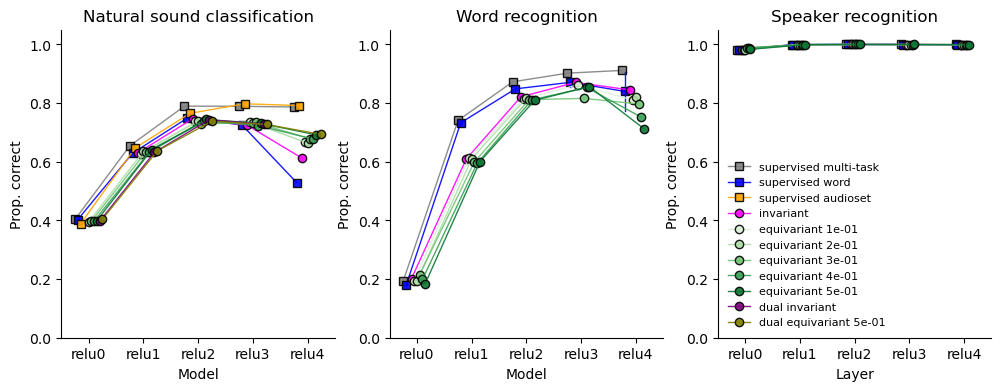

In [29]:
hue_order = [
              'kell2018 supervised multi-task',
              'kell2018 supervised word',
              'kell2018 supervised audioset',
              'kell2018 invariant',
              'kell2018 equivariant 1e-01',
              'kell2018 equivariant 2e-01',
              'kell2018 equivariant 3e-01',
              'kell2018 equivariant 4e-01',
              'kell2018 equivariant 5e-01',
              'kell2018 dual invariant',
              'kell2018 dual equivariant 5e-01',
            #   'kell2018 equivariant 8e-01',
              ]

marker_palette = ['s' if 'supervised' in model else 'o' for model in hue_order]
             
              

# set palette 
hue_dict = {}
hue_dict['kell2018 supervised word'] = 'blue'
hue_dict['kell2018 supervised audioset'] = 'orange' 
hue_dict['kell2018 supervised multi-task'] = 'grey'
hue_dict['kell2018 invariant'] = 'magenta'
hue_dict['kell2018 dual invariant'] = 'purple'
hue_dict['kell2018 dual equivariant 5e-01'] = 'olive'


layer_order = [
            'relu0', 'relu1', 'relu2', 'relu3', 'relu4',
]

eq_model_list = hue_order[4:-2]
equi_palette = sns.color_palette("Greens", n_colors=len(eq_model_list)) 
equi_color_dict = dict(zip(eq_model_list, equi_palette))

hue_dict = {**hue_dict, **equi_color_dict}

esc_50_to_plot = df[(df.arch_class == 'kell2018') & (~df.overall_acc.isna()) & (df.test_layer.str.contains('relu'))]

# esc_50_to_plot = esc_50_to_plot.sort_values('overall_acc', ascending=False).drop_duplicates('model_name')

# esc_50_to_plot = esc_50_to_plot.loc[esc_50_to_plot['test_layer'].map({k: i for i, k in enumerate(kell2018_layer_order)}) \
#                 .sort_values().index]

fig, axes = plt.subplots(1,3, figsize=(12,4))

g = sns.pointplot(data=esc_50_to_plot, 
                order=layer_order,
                hue='model_name', y='overall_acc', #col='arch_class',
                x="test_layer",
                palette=hue_dict,
                hue_order=hue_order,
                alpha=0.9,
                dodge=0.5,
                ax = axes[0],
                legend=False,
                markers=marker_palette,
            # ls='',
                mec='k',
                mew=1,
                lw=1, ms=6
                #  height=4, 
                 )
# g.set_xticklabels(hue_order, rotation=90)
g.set(ylim=(0, 1.05), title="Natural sound classification", ylabel='Prop. correct', xlabel='Model')
# Get current handles and labels
handles, labels = g.get_legend_handles_labels()
# Create a new legend with customized labels and title
# g.legend(handles, labels, frameon=False, ncol=len(labels)//2, fontsize=8)

word_to_plot = df[(df.arch_class == 'kell2018')  & (~df.word_top1_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)

g = sns.pointplot(data=word_to_plot,
                order=layer_order,
                hue='model_name', y='word_top1_mean', 
                x="test_layer",
                palette=hue_dict,
                legend=False,
                hue_order=hue_order,
                alpha=0.9,
                dodge=0.5,
                ax=axes[1],
                 # ls='',
                markers=marker_palette,
                mec='k',
                mew=1,
                lw=1, ms=6
                )
# g.set_xticklabels(labels=hue_order, rotation=90)
g.set(ylim=(0, 1.05), title="Word recognition", ylabel='Prop. correct', xlabel='Model')

speaker_to_plot = df[(df.arch_class == 'kell2018')  & (~df.speaker_top1_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)
g = sns.pointplot(data=speaker_to_plot,
                order=layer_order,
                hue='model_name', y='speaker_top1_mean', 
                x="test_layer", 
                # palette='Blues',
                alpha=0.9,
                dodge=0.3,
                palette=hue_dict,
                hue_order=hue_order,
                ax=axes[2],
                # ls='',
                markers=marker_palette,
                mec='k',
                mew=1,
                lw=1, ms=6
                )
# g.set_xticklabels(labels=hue_order, rotation=90)
g.set(ylim=(0, 1.05), title="Speaker recognition", ylabel='Prop. correct', xlabel='Layer')
handles, labels = g.get_legend_handles_labels()
labels = [label.replace('kell2018 ', '') for label in labels]
# Create a new legend with customized labels and title
g.legend(handles, labels, frameon=False, fontsize=8)

sns.despine()

# plt.suptitle("Kell2018 architecture", y=1.15)
# plt.savefig(outfig_dir/'kell_sup_v_ssl_on_tasks.png', transparent=True,dpi=500,  bbox_inches='tight')


/tmp/ipykernel_1659887/3500835333.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=model_names_for_x, rotation=90, ) #ha='right', rotation_mode='anchor')
/tmp/ipykernel_1659887/3500835333.py:90: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=model_names_for_x, rotation=90, ) #ha='right', rotation_mode='anchor')


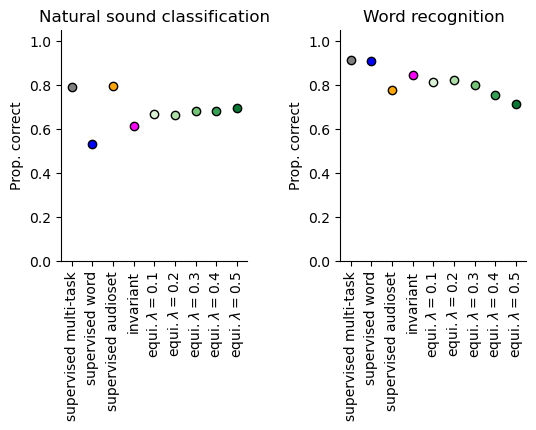

In [ ]:
hue_order = [
              'kell2018 supervised multi-task',
              'kell2018 supervised word',
              'kell2018 supervised audioset',
            #   'byol-a', 
              'kell2018 invariant',
              'kell2018 equivariant 1e-01',
              'kell2018 equivariant 2e-01',
              'kell2018 equivariant 3e-01',
              'kell2018 equivariant 4e-01',
              'kell2018 equivariant 5e-01',
            #   'kell2018 equivariant 8e-01',
              ]

model_names_for_x = []

for name in hue_order:
    name = name.replace('kell2018 ', '')
    if "e-01" in name:
        eq, lmbda = name.split(' ')
        name = f"equi. $\\lambda=${float(lmbda)}"
    model_names_for_x.append(name)

# set palette 
hue_dict = {}
hue_dict['kell2018 supervised word'] = 'blue'
hue_dict['kell2018 supervised audioset'] = 'orange' 
hue_dict['kell2018 supervised multi-task'] = 'grey'
hue_dict['kell2018 invariant'] = 'magenta'
# hue_dict['byol-a'] = 'k'



eq_model_list = hue_order[4:]
equi_palette = sns.color_palette("Greens", n_colors=len(eq_model_list)) 
equi_color_dict = dict(zip(eq_model_list, equi_palette))

hue_dict = {**hue_dict, **equi_color_dict}

fig, axs = plt.subplots(1,2, figsize=(6,3))
to_plot  = df[df.model_name.str.contains('kell2018|byol')].copy()

test_layers = ['relu4', 'final', 'avgpool']

to_plot = to_plot[(to_plot.model_name.isin(hue_order)) & to_plot.test_layer.isin(test_layers)]
to_plot = to_plot[~((to_plot.model_name.str.contains('kell')) & to_plot.test_layer.str.contains('avgpool'))]
# models_for_esc = ['kell2018 supervised word', 'kell2018 supervised multi-task', 'byol-a ']
# esc_50_to_plot = esc_50_to_plot[esc_50_to_plot.model_name.str.contains('kell2018|byola')]
g = sns.pointplot(data=to_plot,
                order=hue_order,
                x='model_name',
                y='overall_acc',
                # col='arch_class',
                hue="model_name",
                palette=hue_dict,

                # hue_order=hue_order,
                # height=4,
                ax = axs[0],
                mec='k',
                mew=1,
                lw=1, ms=6
                )

g.set_xticklabels(labels=model_names_for_x, rotation=90, ) #ha='right', rotation_mode='anchor')
g.set(ylim=(0., 1.05), title="Natural sound classification", ylabel='Prop. correct', xlabel='')
sns.despine()


# word_to_plot = to_plot[(~to_plot.word_top1_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)

word_to_plot = to_plot[~((to_plot.model_name.str.contains('byol')) & to_plot.test_layer.str.contains('final'))].drop_duplicates('model_name')

g = sns.pointplot(data=word_to_plot,
                order=hue_order,
                x='model_name',
                y='word_top1_mean',
                # col='arch_class',
                hue="model_name",
                palette=hue_dict,

                # hue_order=hue_order,
                # height=4,
                ax = axs[1],
                mec='k',
                mew=1,
                lw=1, ms=6
                )

g.set_xticklabels(labels=model_names_for_x, rotation=90, ) #ha='right', rotation_mode='anchor')
g.set(ylim=(0, 1.05), title="Word recognition", ylabel='Prop. correct', xlabel='')
sns.despine()

plt.subplots_adjust(wspace=0.5)

# speaker_to_plot = to_plot[(~to_plot.speaker_top1_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)
# speaker_to_plot = speaker_to_plot.sort_values('speaker_top1_mean', ascending=False).drop_duplicates('model_name')

# g = sns.pointplot(data=to_plot,
#                 order=hue_order,
#                 hue="model_name",
#                 palette=hue_dict,
#                 y='speaker_top1_mean', 
#                 x="model_name", 
#                 ax=axs[2],
#                 # ls='',
#                 # markers=marker_palette,
#                 mec='k',
#                 mew=1,
#                 lw=1, ms=6
#                 )
# # g.set_xticklabels(labels=model_names_for_x, rotation=90)
# g.set(ylim=(0, 1.05), title="Speaker recognition", ylabel='Prop. correct', xlabel='')
# g.set_xticklabels(labels=model_names_for_x, rotation=90,)# ) #ha='right', rotation_mode='anchor')

# # handles, labels = g.get_legend_handles_labels()
# labels = [label.replace('kell2018 ', '') for label in labels]
# Create a new legend with customized labels and title
# g.legend(handles, labels, frameon=False, fontsize=8)

sns.despine()


# plt.savefig(outfig_dir/'all_models_speech_esc_relu4.png', transparent=True,dpi=500,  bbox_inches='tight')



ValueError: The palette dictionary is missing keys: {'kell2018 equivariant 1e-01'}

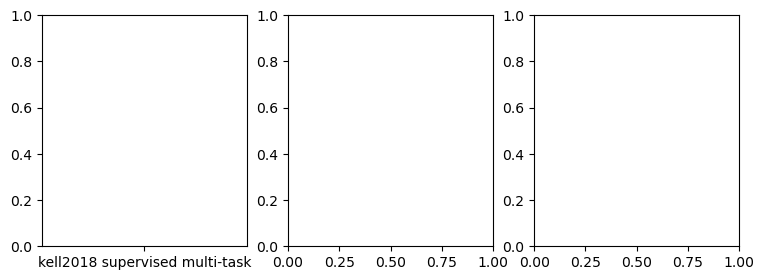

In [17]:
hue_order = [
              'kell2018 supervised multi-task',
              'kell2018 supervised word',
              'kell2018 supervised audioset',
            #   'byol-a', 
              'kell2018 invariant',
              'kell2018 equivariant 1e-01',
              'kell2018 equivariant 2e-01',
              'kell2018 equivariant 3e-01',
              'kell2018 equivariant 4e-01',
              'kell2018 equivariant 5e-01',
            #   'kell2018 equivariant 8e-01',
              ]

model_names_for_x = []

for name in hue_order:
    name = name.replace('kell2018 ', '')
    if "e-01" in name:
        eq, lmbda = name.split(' ')
        name = f"equi. $\\lambda=${float(lmbda)}"
    model_names_for_x.append(name)

# set palette 
hue_dict = {}
hue_dict['kell2018 supervised word'] = 'blue'
hue_dict['kell2018 supervised audioset'] = 'orange' 
hue_dict['kell2018 supervised multi-task'] = 'grey'
hue_dict['kell2018 invariant'] = 'magenta'
# hue_dict['byol-a'] = 'k'



eq_model_list = hue_order[5:]
equi_palette = sns.color_palette("Greens", n_colors=len(eq_model_list)) 
equi_color_dict = dict(zip(eq_model_list, equi_palette))

hue_dict = {**hue_dict, **equi_color_dict}

fig, axs = plt.subplots(1,3, figsize=(9,3))
to_plot  = df[df.model_name.str.contains('kell2018|byol')].copy()

test_layers = ['relu4', 'final', 'avgpool']

to_plot = to_plot[(to_plot.model_name.isin(hue_order)) & to_plot.test_layer.isin(test_layers)]
to_plot = to_plot[~((to_plot.model_name.str.contains('kell')) & to_plot.test_layer.str.contains('avgpool'))]
# models_for_esc = ['kell2018 supervised word', 'kell2018 supervised multi-task', 'byol-a ']
# esc_50_to_plot = esc_50_to_plot[esc_50_to_plot.model_name.str.contains('kell2018|byola')]
g = sns.pointplot(data=to_plot,
                order=hue_order,
                x='model_name',
                y='overall_acc',
                # col='arch_class',
                hue="model_name",
                palette=hue_dict,

                # hue_order=hue_order,
                # height=4,
                ax = axs[0],
                mec='k',
                mew=1,
                lw=1, ms=6
                )

g.set_xticklabels(labels=model_names_for_x, rotation=90, ) #ha='right', rotation_mode='anchor')
g.set(ylim=(0., 1.05), title="Natural sound classification", ylabel='Prop. correct', xlabel='')
sns.despine()


# word_to_plot = to_plot[(~to_plot.word_top1_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)

word_to_plot = to_plot[~((to_plot.model_name.str.contains('byol')) & to_plot.test_layer.str.contains('final'))].drop_duplicates('model_name')

g = sns.pointplot(data=word_to_plot,
                order=hue_order,
                x='model_name',
                y='word_top1_mean',
                # col='arch_class',
                hue="model_name",
                palette=hue_dict,

                # hue_order=hue_order,
                # height=4,
                ax = axs[1],
                mec='k',
                mew=1,
                lw=1, ms=6
                )

g.set_xticklabels(labels=model_names_for_x, rotation=90, ) #ha='right', rotation_mode='anchor')
g.set(ylim=(0, 1.05), title="Word recognition", ylabel='Prop. correct', xlabel='')
sns.despine()

plt.subplots_adjust(wspace=0.5)

# speaker_to_plot = to_plot[(~to_plot.speaker_top1_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)
# speaker_to_plot = speaker_to_plot.sort_values('speaker_top1_mean', ascending=False).drop_duplicates('model_name')

g = sns.pointplot(data=to_plot,
                order=hue_order,
                hue="model_name",
                palette=hue_dict,
                y='speaker_top1_mean', 
                x="model_name", 
                ax=axs[2],
                # ls='',
                # markers=marker_palette,
                mec='k',
                mew=1,
                lw=1, ms=6
                )
# g.set_xticklabels(labels=model_names_for_x, rotation=90)
g.set(ylim=(0, 1.05), title="Speaker recognition", ylabel='Prop. correct', xlabel='')
g.set_xticklabels(labels=model_names_for_x, rotation=90,)# ) #ha='right', rotation_mode='anchor')

# handles, labels = g.get_legend_handles_labels()
# labels = [label.replace('kell2018 ', '') for label in labels]
# Create a new legend with customized labels and title
# g.legend(handles, labels, frameon=False, fontsize=8)

sns.despine()


# plt.savefig(outfig_dir/'all_models_per_task_relu4.png', transparent=True,dpi=500,  bbox_inches='tight')



/tmp/ipykernel_584233/1910310872.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=model_names_for_x, rotation=45, ha='right', rotation_mode='anchor')
/tmp/ipykernel_584233/1910310872.py:84: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=model_names_for_x, rotation=45, ha='right', rotation_mode='anchor')
/tmp/ipykernel_584233/1910310872.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=model_names_for_x, rotation=45, ha='right', rotation_mode='anchor')


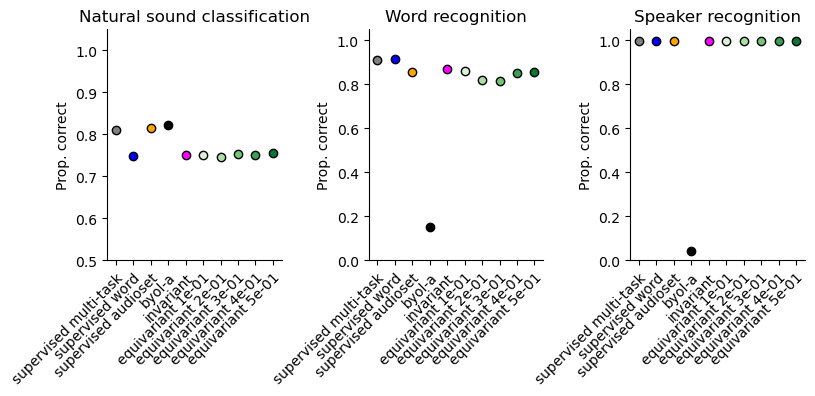

In [86]:
hue_order = [
              'kell2018 supervised multi-task',
              'kell2018 supervised word',
              'kell2018 supervised audioset',
              'byol-a', 
              'kell2018 invariant',
              'kell2018 equivariant 1e-01',
              'kell2018 equivariant 2e-01',
              'kell2018 equivariant 3e-01',
              'kell2018 equivariant 4e-01',
              'kell2018 equivariant 5e-01',
            #   'kell2018 equivariant 8e-01',
              ]

model_names_for_x = [x.replace('kell2018 ', '') for x in hue_order]
# set palette 
hue_dict = {}
hue_dict['kell2018 supervised word'] = 'blue'
hue_dict['kell2018 supervised audioset'] = 'orange' 
hue_dict['kell2018 supervised multi-task'] = 'grey'
hue_dict['kell2018 invariant'] = 'magenta'
hue_dict['byol-a'] = 'k'


layer_order = [
            'relu0', 'relu1', 'relu2', 'relu3', 'relu4',
]

eq_model_list = hue_order[5:]
equi_palette = sns.color_palette("Greens", n_colors=len(eq_model_list)) 
equi_color_dict = dict(zip(eq_model_list, equi_palette))

hue_dict = {**hue_dict, **equi_color_dict}

fig, axs = plt.subplots(1,3, figsize=(9,3))
to_plot  = df[df.model_name.str.contains('kell2018|byol')].copy()

esc_50_to_plot = to_plot.sort_values('overall_acc', ascending=False).drop_duplicates('model_name')
esc_50_to_plot = esc_50_to_plot[esc_50_to_plot.model_name.isin(hue_order)]
# models_for_esc = ['kell2018 supervised word', 'kell2018 supervised multi-task', 'byol-a ']
# esc_50_to_plot = esc_50_to_plot[esc_50_to_plot.model_name.str.contains('kell2018|byola')]
g = sns.pointplot(data=esc_50_to_plot,
                order=hue_order,
                x='model_name',
                y='overall_acc',
                # col='arch_class',
                hue="model_name",
                palette=hue_dict,

                # hue_order=hue_order,
                # height=4,
                ax = axs[0],
                mec='k',
                mew=1,
                lw=1, ms=6
                )

g.set_xticklabels(labels=model_names_for_x, rotation=45, ha='right', rotation_mode='anchor')
g.set(ylim=(0.5, 1.05), title="Natural sound classification", ylabel='Prop. correct', xlabel='')
sns.despine()


word_to_plot = to_plot[(~to_plot.word_top1_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)

word_to_plot = word_to_plot.sort_values('word_top1_mean', ascending=False).drop_duplicates('model_name')
# models_for_word = ['kell2018 supervised word', 'kell2018 supervised multi-task', 'byol-a ']
# word_to_plot = word_to_plot[word_to_plot.model_name.str.contains('kell2018|byola')]
g = sns.pointplot(data=word_to_plot,
                order=hue_order,
                x='model_name',
                y='word_top1_mean',
                # col='arch_class',
                hue="model_name",
                palette=hue_dict,

                # hue_order=hue_order,
                # height=4,
                ax = axs[1],
                mec='k',
                mew=1,
                lw=1, ms=6
                )

g.set_xticklabels(labels=model_names_for_x, rotation=45, ha='right', rotation_mode='anchor')
g.set(ylim=(0, 1.05), title="Word recognition", ylabel='Prop. correct', xlabel='')
sns.despine()

plt.subplots_adjust(wspace=0.5)

speaker_to_plot = to_plot[(~to_plot.speaker_top1_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)
speaker_to_plot = speaker_to_plot.sort_values('speaker_top1_mean', ascending=False).drop_duplicates('model_name')

g = sns.pointplot(data=speaker_to_plot,
                order=hue_order,
                hue="model_name",
                palette=hue_dict,
                y='speaker_top1_mean', 
                x="model_name", 
                ax=axs[2],
                # ls='',
                # markers=marker_palette,
                mec='k',
                mew=1,
                lw=1, ms=6
                )
# g.set_xticklabels(labels=model_names_for_x, rotation=90)
g.set(ylim=(0, 1.05), title="Speaker recognition", ylabel='Prop. correct', xlabel='')
g.set_xticklabels(labels=model_names_for_x, rotation=45, ha='right', rotation_mode='anchor')

# handles, labels = g.get_legend_handles_labels()
# labels = [label.replace('kell2018 ', '') for label in labels]
# Create a new legend with customized labels and title
# g.legend(handles, labels, frameon=False, fontsize=8)

sns.despine()


# plt.savefig(outfig_dir/'byola_vs_sup_ranking.png', transparent=True,dpi=500,  bbox_inches='tight')



In [29]:
from lightning_scripts.byola_lightning_module import BYOLAModule
import yaml 
config = yaml.load(open('byol-a/config.yaml', 'r'), Loader=yaml.FullLoader)

module = BYOLAModule(config)

/mnt/ceph/users/igriffith/projects/cochdnn/byol-a/byol_a/models.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = state_dict or torch.load(weight_file, map_l

Text(0.5, 1.15, 'Kell2018 architecture')

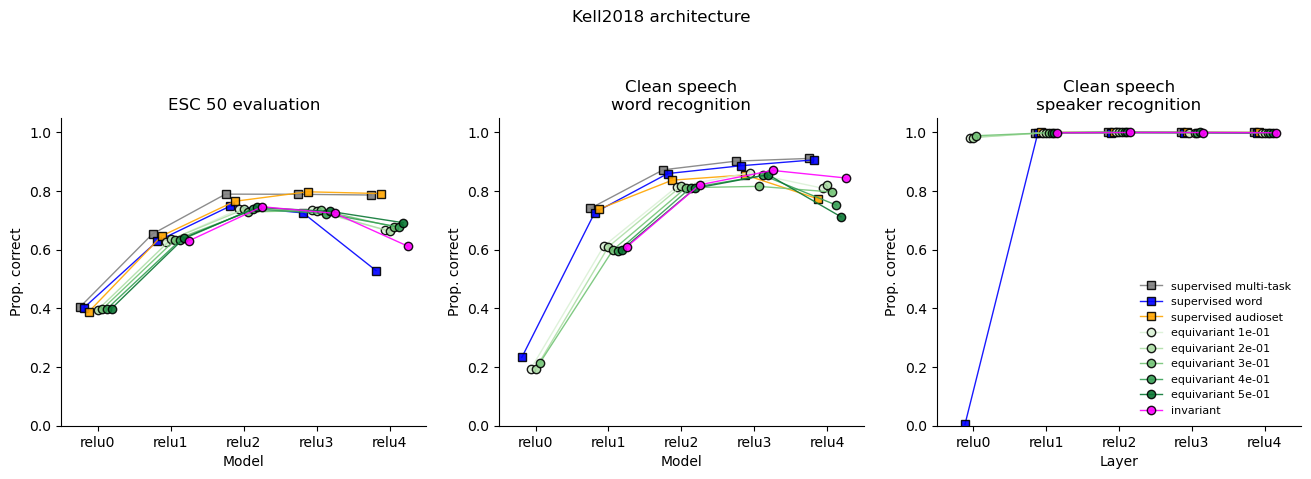

In [131]:
hue_order = [
              'kell2018 supervised multi-task',
              'kell2018 supervised word',
              'kell2018 supervised audioset',
              'kell2018 equivariant 1e-01',
              'kell2018 equivariant 2e-01',
              'kell2018 equivariant 3e-01',
              'kell2018 equivariant 4e-01',
              'kell2018 equivariant 5e-01',
            #   'kell2018 equivariant 8e-01',
              'kell2018 invariant',
              ]

marker_palette = ['s' if 'supervised' in model else 'o' for model in hue_order]
             
              

# set palette 
hue_dict = {}
hue_dict['kell2018 supervised word'] = 'blue'
hue_dict['kell2018 supervised audioset'] = 'orange' 
hue_dict['kell2018 supervised multi-task'] = 'grey'
hue_dict['kell2018 invariant'] = 'magenta'


layer_order = [
            'relu0', 'relu1', 'relu2', 'relu3', 'relu4',
]

eq_model_list = hue_order[3:-1]
equi_palette = sns.color_palette("Greens", n_colors=len(eq_model_list)) 
equi_color_dict = dict(zip(eq_model_list, equi_palette))

hue_dict = {**hue_dict, **equi_color_dict}

esc_50_to_plot = df[(df.arch_class == 'kell2018') & (~df.overall_acc.isna()) & (df.test_layer.str.contains('relu'))]

# esc_50_to_plot = esc_50_to_plot.sort_values('overall_acc', ascending=False).drop_duplicates('model_name')

# esc_50_to_plot = esc_50_to_plot.loc[esc_50_to_plot['test_layer'].map({k: i for i, k in enumerate(kell2018_layer_order)}) \
#                 .sort_values().index]

fig, axes = plt.subplots(1,3, figsize=(16,4))

g = sns.pointplot(data=esc_50_to_plot, 
                order=layer_order,
                hue='model_name', y='overall_acc', #col='arch_class',
                x="test_layer",
                palette=hue_dict,
                hue_order=hue_order,
                alpha=0.9,
                dodge=0.5,
                ax = axes[0],
                legend=False,
                markers=marker_palette,
            # ls='',
                mec='k',
                mew=1,
                lw=1, ms=6
                #  height=4, 
                 )
# g.set_xticklabels(hue_order, rotation=90)
g.set(ylim=(0, 1.05), title="ESC 50 evaluation", ylabel='Prop. correct', xlabel='Model')
# Get current handles and labels
handles, labels = g.get_legend_handles_labels()
# Create a new legend with customized labels and title
# g.legend(handles, labels, frameon=False, ncol=len(labels)//2, fontsize=8)

word_to_plot = df[(df.arch_class == 'kell2018')  & (~df.word_top1_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)

g = sns.pointplot(data=word_to_plot,
                order=layer_order,
                hue='model_name', y='word_top1_mean', 
                x="test_layer",
                palette=hue_dict,
                legend=False,
                hue_order=hue_order,
                alpha=0.9,
                dodge=0.5,
                ax=axes[1],
                 # ls='',
                markers=marker_palette,
                mec='k',
                mew=1,
                lw=1, ms=6
                )
# g.set_xticklabels(labels=hue_order, rotation=90)
g.set(ylim=(0, 1.05), title="Clean speech\nword recognition", ylabel='Prop. correct', xlabel='Model')

speaker_to_plot = df[(df.arch_class == 'kell2018')  & (~df.speaker_top1_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)
g = sns.pointplot(data=speaker_to_plot,
                order=layer_order,
                hue='model_name', y='speaker_top1_mean', 
                x="test_layer", 
                # palette='Blues',
                alpha=0.9,
                dodge=0.3,
                palette=hue_dict,
                hue_order=hue_order,
                ax=axes[2],
                # ls='',
                markers=marker_palette,
                mec='k',
                mew=1,
                lw=1, ms=6
                )
# g.set_xticklabels(labels=hue_order, rotation=90)
g.set(ylim=(0, 1.05), title="Clean speech\nspeaker recognition", ylabel='Prop. correct', xlabel='Layer')
handles, labels = g.get_legend_handles_labels()
labels = [label.replace('kell2018 ', '') for label in labels]
# Create a new legend with customized labels and title
g.legend(handles, labels, frameon=False, fontsize=8)

sns.despine()

plt.suptitle("Kell2018 architecture", y=1.15)

## Colorblind friendly palette 

Text(0.5, 1.15, 'Kell2018 architecture')

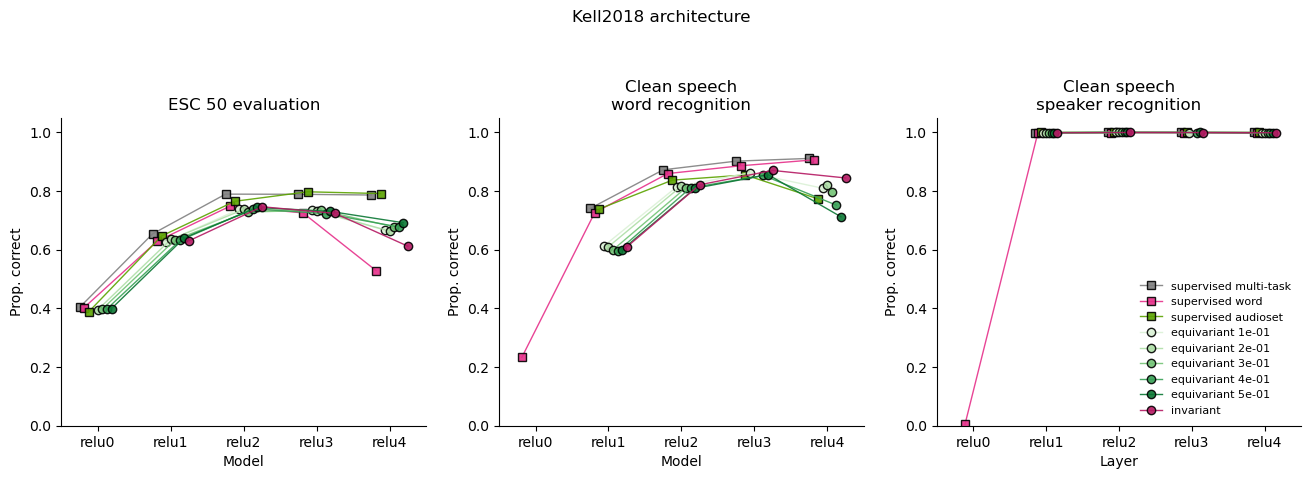

In [38]:
hue_order = [
              'kell2018 supervised multi-task',
              'kell2018 supervised word',
              'kell2018 supervised audioset',
              'kell2018 equivariant 1e-01',
              'kell2018 equivariant 2e-01',
              'kell2018 equivariant 3e-01',
              'kell2018 equivariant 4e-01',
              'kell2018 equivariant 5e-01',
            #   'kell2018 equivariant 8e-01',
              'kell2018 invariant',
              ]

marker_palette = ['s' if 'supervised' in model else 'o' for model in hue_order]
             
              

# set palette 
hue_dict = {}
hue_dict['kell2018 supervised word'] = '#e6308a'
hue_dict['kell2018 supervised audioset'] = '#5ba300' 
hue_dict['kell2018 supervised multi-task'] = 'grey'
hue_dict['kell2018 invariant'] = '#b51963'


layer_order = [
            'relu0', 'relu1', 'relu2', 'relu3', 'relu4', #'relufc'
]

eq_model_list = hue_order[3:-1]
equi_palette = sns.color_palette("Greens", n_colors=len(eq_model_list)) 
equi_color_dict = dict(zip(eq_model_list, equi_palette))

hue_dict = {**hue_dict, **equi_color_dict}

esc_50_to_plot = df[(df.arch_class == 'kell2018') & (~df.overall_acc.isna()) & (df.test_layer.str.contains('relu'))]

# esc_50_to_plot = esc_50_to_plot.sort_values('overall_acc', ascending=False).drop_duplicates('model_name')

# esc_50_to_plot = esc_50_to_plot.loc[esc_50_to_plot['test_layer'].map({k: i for i, k in enumerate(kell2018_layer_order)}) \
#                 .sort_values().index]

fig, axes = plt.subplots(1,3, figsize=(16,4))

g = sns.pointplot(data=esc_50_to_plot, 
                order=layer_order,
                hue='model_name', y='overall_acc', #col='arch_class',
                x="test_layer",
                palette=hue_dict,
                hue_order=hue_order,
                alpha=0.9,
                dodge=0.5,
                ax = axes[0],
                legend=False,
                markers=marker_palette,
            # ls='',
                mec='k',
                mew=1,
                lw=1, ms=6
                #  height=4, 
                 )
# g.set_xticklabels(hue_order, rotation=90)
g.set(ylim=(0, 1.05), title="ESC 50 evaluation", ylabel='Prop. correct', xlabel='Model')
# Get current handles and labels
handles, labels = g.get_legend_handles_labels()
# Create a new legend with customized labels and title
# g.legend(handles, labels, frameon=False, ncol=len(labels)//2, fontsize=8)

word_to_plot = df[(df.arch_class == 'kell2018')  & (~df.word_top1_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)

g = sns.pointplot(data=word_to_plot,
                order=layer_order,
                hue='model_name', y='word_top1_mean', 
                x="test_layer",
                palette=hue_dict,
                legend=False,
                hue_order=hue_order,
                alpha=0.9,
                dodge=0.5,
                ax=axes[1],
                 # ls='',
                markers=marker_palette,
                mec='k',
                mew=1,
                lw=1, ms=6
                )
# g.set_xticklabels(labels=hue_order, rotation=90)
g.set(ylim=(0, 1.05), title="Clean speech\nword recognition", ylabel='Prop. correct', xlabel='Model')

speaker_to_plot = df[(df.arch_class == 'kell2018')  & (~df.speaker_top1_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)
g = sns.pointplot(data=speaker_to_plot,
                order=layer_order,
                hue='model_name', y='speaker_top1_mean', 
                x="test_layer", 
                # palette='Blues',
                alpha=0.9,
                dodge=0.3,
                palette=hue_dict,
                hue_order=hue_order,
                ax=axes[2],
                # ls='',
                markers=marker_palette,
                mec='k',
                mew=1,
                lw=1, ms=6
                )
# g.set_xticklabels(labels=hue_order, rotation=90)
g.set(ylim=(0, 1.05), title="Clean speech\nspeaker recognition", ylabel='Prop. correct', xlabel='Layer')
handles, labels = g.get_legend_handles_labels()
labels = [label.replace('kell2018 ', '') for label in labels]
# Create a new legend with customized labels and title
g.legend(handles, labels, frameon=False, fontsize=8)

sns.despine()

plt.suptitle("Kell2018 architecture", y=1.15)

/tmp/ipykernel_809332/2115467154.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(hue_order, rotation=90)
/tmp/ipykernel_809332/2115467154.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=hue_order, rotation=90)
/tmp/ipykernel_809332/2115467154.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=hue_order, rotation=90)


Text(0.5, 1.15, 'Kell2018 architecture')

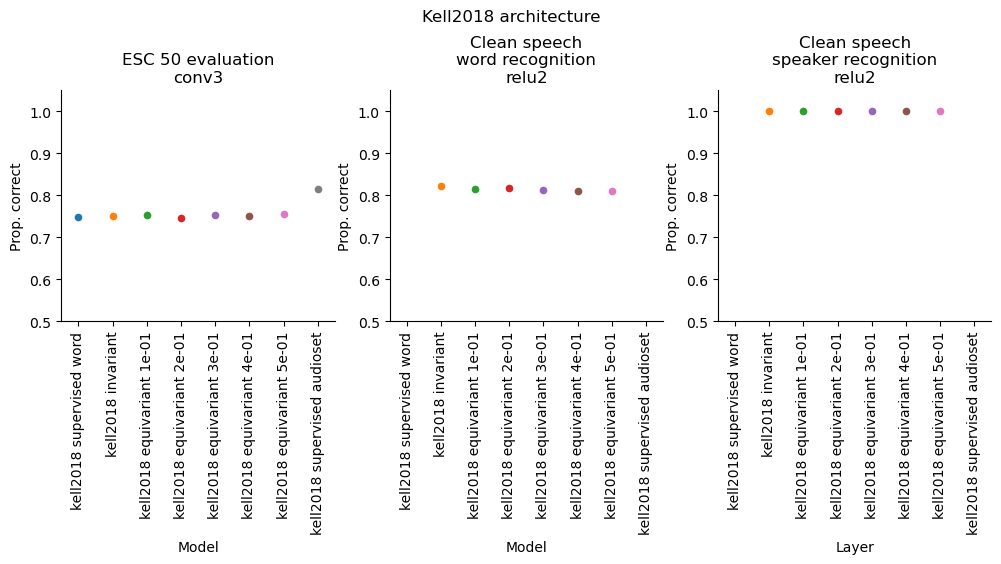

In [31]:
hue_order = [
              'kell2018 supervised word',
              'kell2018 invariant',
              'kell2018 equivariant 1e-01',
              'kell2018 equivariant 2e-01',
              'kell2018 equivariant 3e-01',
              'kell2018 equivariant 4e-01',
              'kell2018 equivariant 5e-01',
              'kell2018 supervised audioset'
              ]

test_layer = 'relu2'

# hue_dict = {}
# hue_dict['kell2018 invariant '] = 'k'
# hue_dict['kell2018 supervised audioset '] = 'tab:orange'

# equi_palette = sns.color_palette("crest", n_colors=len(hue_order[1:-1])) 
# equi_color_dict = dict(zip(hue_order[1:-1], equi_palette))

# hue_dict = {**hue_dict, **equi_color_dict}

esc_50_to_plot = df[(df.arch_class == 'kell2018') & (~df.overall_acc.isna())]

esc_50_to_plot = esc_50_to_plot.sort_values('overall_acc', ascending=False).drop_duplicates('model_name')

# esc_50_to_plot = esc_50_to_plot.loc[esc_50_to_plot['test_layer'].map({k: i for i, k in enumerate(kell2018_layer_order)}) \
#                 .sort_values().index]

fig, axes = plt.subplots(1,3, figsize=(12,3))

g = sns.pointplot(data=esc_50_to_plot, 
                order=hue_order,
                 x='model_name', y='overall_acc', #col='arch_class',
                  hue="model_name",
                # palette=hue_dict,
                hue_order=hue_order,
                ax = axes[0],
                #  height=4, 
                 lw=2, ms=4)
g.set_xticklabels(hue_order, rotation=90)
g.set(ylim=(0.5, 1.05), title="ESC 50 evaluation\nconv3", ylabel='Prop. correct', xlabel='Model')

word_to_plot = df[(df.arch_class == 'kell2018') & (df.test_layer==test_layer) & (~df.word_top1_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)

g = sns.pointplot(data=word_to_plot,
                order=hue_order,
                x='model_name', y='word_top1_mean', 
                hue="model_name",
                # palette=hue_dict,
                hue_order=hue_order,
                ax=axes[1],
                lw=2, ms=4)
g.set_xticklabels(labels=hue_order, rotation=90)
g.set(ylim=(0.5, 1.05), title="Clean speech\nword recognition\nrelu2", ylabel='Prop. correct', xlabel='Model')

speaker_to_plot = df[(df.arch_class == 'kell2018') & (df.test_layer==test_layer) & (~df.speaker_top1_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)
g = sns.pointplot(data=speaker_to_plot,
                order=hue_order,
                x='model_name', y='speaker_top1_mean', 
                hue="model_name", 
                # palette=hue_dict,
                hue_order=hue_order,
                ax=axes[2],

                lw=2, ms=4)
g.set_xticklabels(labels=hue_order, rotation=90)
g.set(ylim=(0.5, 1.05), title="Clean speech\nspeaker recognition\nrelu2", ylabel='Prop. correct', xlabel='Layer')
sns.despine()
# word_to_plot = df[(df.arch_class == 'kell2018') & (df.test_layer==test_layer) & (~df.word_top5_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)
# g = sns.pointplot(data=word_to_plot,
#                 order=hue_order,
#                 x='model_name', y='word_top5_mean', 
#                 hue="model_name", 
#                 # palette=hue_dict,
#                 hue_order=hue_order,
#                 ax=axes[2],

#                 lw=2, ms=4)
# g.set_xticklabels(labels=hue_order[:-1], rotation=90)
# g.set(ylim=(0, 1), ylabel='Word top-5 prop. correct', xlabel='Layer')
# plt.tight_layout()

# axes[0].legend(frameon=False, fontsize=7, ncol=1,)
plt.suptitle("Kell2018 architecture", y=1.15)

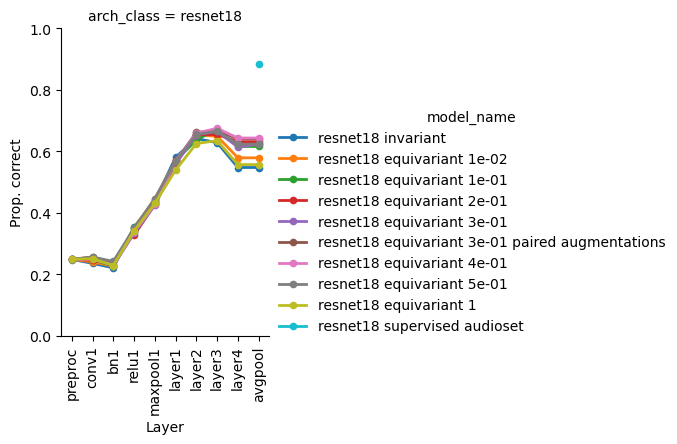

In [32]:
hue_order = [
              'resnet18 invariant',
              'resnet18 equivariant 1e-02',
              'resnet18 equivariant 1e-01',
              'resnet18 equivariant 2e-01',
              'resnet18 equivariant 3e-01',
              'resnet18 equivariant 3e-01 paired augmentations',
              'resnet18 equivariant 4e-01',
              'resnet18 equivariant 5e-01',
              'resnet18 equivariant 1',
              'resnet18 supervised audioset']


# hue_dict = {}
# hue_dict['resnet18 invariant'] = 'k'
# hue_dict['resnet18 supervised audioset'] = 'tab:orange'

# equi_palette = sns.color_palette("crest", n_colors=len(hue_order[1:-1])) 
# equi_color_dict = dict(zip(hue_order[1:-1], equi_palette))

# hue_dict = {**hue_dict, **equi_color_dict}

g = sns.catplot(data=df[df.arch_class == 'resnet18'], 
                order=resnet18_layer_order,
                kind='point', x='test_layer', y='overall_acc', col='arch_class',
                hue="model_name", 
                # palette=hue_dict,
                hue_order=hue_order,
                 height=4, lw=2, ms=4)
g.set_xticklabels(rotation=90)
g.set(ylim=(0, 1), ylabel='Prop. correct', xlabel='Layer')

/tmp/ipykernel_809332/2818080575.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(hue_order, rotation=90)
/tmp/ipykernel_809332/2818080575.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=hue_order[:-1], rotation=90)
/tmp/ipykernel_809332/2818080575.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=hue_order[:-1], rotation=90)


[(0.0, 1.0), Text(0, 0.5, 'Word top-5 prop. correct'), Text(0.5, 0, 'Layer')]

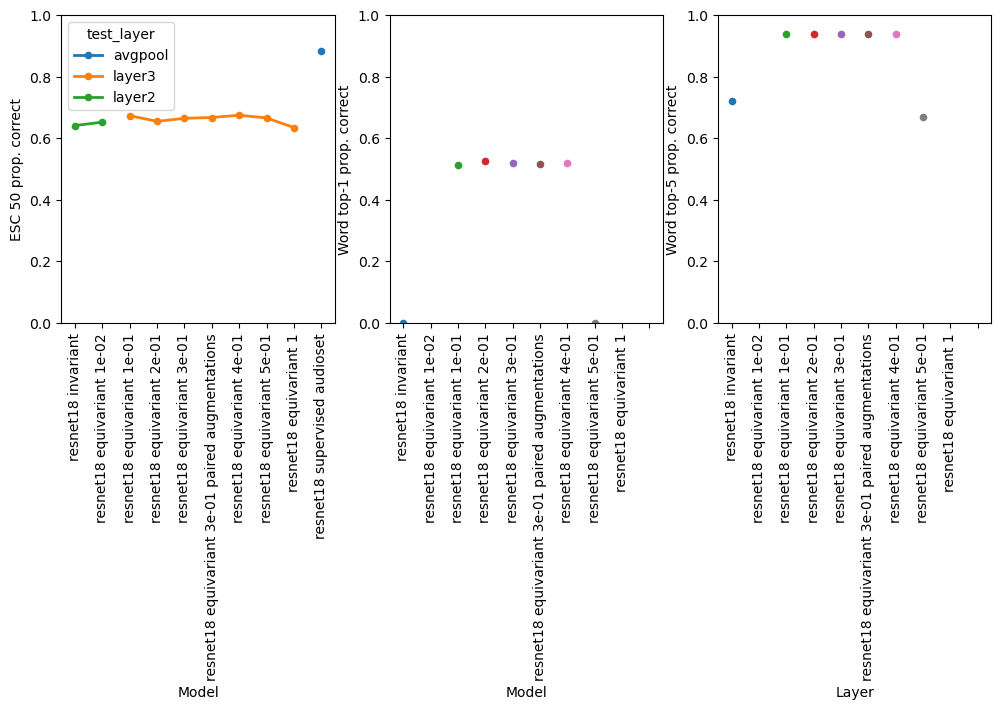

In [ ]:
hue_order = [
              'resnet18 invariant',
              'resnet18 equivariant 1e-02',
              'resnet18 equivariant 1e-01',
              'resnet18 equivariant 2e-01',
              'resnet18 equivariant 3e-01',
              'resnet18 equivariant 3e-01 paired augmentations',
              'resnet18 equivariant 4e-01',
              'resnet18 equivariant 5e-01',
              'resnet18 equivariant 1',
              'resnet18 supervised audioset']

test_layer = 'layer2'

# hue_dict = {}
# hue_dict['resnet18 invariant '] = 'k'
# hue_dict['resnet18 supervised audioset '] = 'tab:orange'

# equi_palette = sns.color_palette("crest", n_colors=len(hue_order[1:-1])) 
# equi_color_dict = dict(zip(hue_order[1:-1], equi_palette))

# hue_dict = {**hue_dict, **equi_color_dict}

esc_50_to_plot = df[(df.arch_class == 'resnet18') & (~df.overall_acc.isna())]

esc_50_to_plot = esc_50_to_plot.sort_values('overall_acc', ascending=False).drop_duplicates('model_name')

# esc_50_to_plot = esc_50_to_plot.loc[esc_50_to_plot['test_layer'].map({k: i for i, k in enumerate(resnet18_layer_order)}) \
#                 .sort_values().index]

fig, axes = plt.subplots(1,3, figsize=(12,4))

g = sns.pointplot(data=esc_50_to_plot, 
                order=hue_order,
                 x='model_name', y='overall_acc', #col='arch_class',
                  hue="test_layer",
                # palette=hue_dict,
                # hue_order=hue_order,
                ax = axes[0],
                
                #  height=4, 
                 lw=2, ms=4)
g.set_xticklabels(hue_order, rotation=90)
g.set(ylim=(0, 1), ylabel='ESC 50 prop. correct', xlabel='Model')

word_to_plot = df[(df.arch_class == 'resnet18') & (df.test_layer==test_layer) & (~df.word_top1_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)

g = sns.pointplot(data=word_to_plot,
                order=hue_order,
                x='model_name', y='word_top1_mean', 
                hue="model_name",
                # palette=hue_dict,
                hue_order=hue_order,
                ax=axes[1],
                lw=2, ms=4)
g.set_xticklabels(labels=hue_order[:-1], rotation=90)
g.set(ylim=(0, 1), ylabel='Word top-1 prop. correct', xlabel='Model')

word_to_plot = df[(df.arch_class == 'resnet18') & (df.test_layer==test_layer) & (~df.word_top5_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)
g = sns.pointplot(data=word_to_plot,
                order=hue_order,
                x='model_name', y='word_top5_mean', 
                hue="model_name", 
                # palette=hue_dict,
                hue_order=hue_order,
                ax=axes[2],

                lw=2, ms=4)
g.set_xticklabels(labels=hue_order[:-1], rotation=90)
g.set(ylim=(0, 1), ylabel='Word top-5 prop. correct', xlabel='Layer')
# plt.tight_layout()

# axes[0].legend(frameon=False, fontsize=7, ncol=1,)

In [12]:
word_to_plot

,model_name,arch_class,test_layer,eq_lmbda,word_top1_mean,word_top1_sem,word_top5_mean,word_top5_sem
0,resnet18 equivariant 1e-01,resnet18,layer2,1e-01,0.514917,0.000815,0.937214,0.000426
1,resnet18 equivariant 3e-01,resnet18,layer2,3e-01,0.523625,0.000832,0.939089,0.000426
2,resnet18 equivariant 3e-01 paired augmentations,resnet18,layer2,3e-01,0.520784,0.000845,0.938471,0.000422
3,resnet18 equivariant 5e-01,resnet18,layer2,5e-01,0.001121,0.000056,0.668512,0.003311
4,resnet18 invariant,resnet18,layer2,,0.001508,0.000063,0.722399,0.002293
5,resnet18 equivariant 3e-01 paired augmentations,resnet18,layer2,3e-01,0.515514,0.000853,0.937791,0.000427
6,resnet18 equivariant 4e-01,resnet18,layer2,4e-01,0.521239,0.000842,0.937557,0.000431
7,resnet18 equivariant 2e-01,resnet18,layer2,2e-01,0.526651,0.000835,0.938880,0.000421
8,resnet18 equivariant 3e-01,resnet18,layer2,3e-01,0.518387,0.000839,0.938418,0.000431


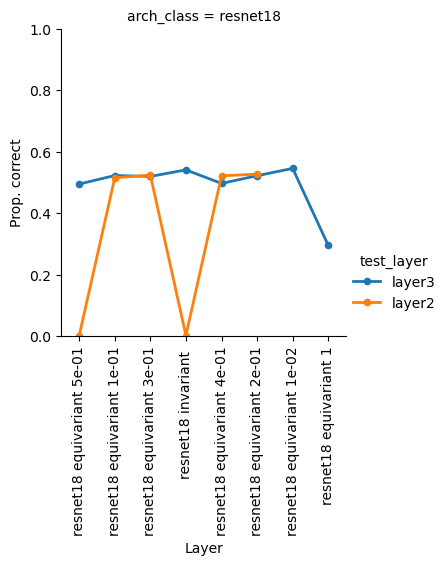

In [90]:
# hue_order = [
#               'resnet18 invariant ',
#               'resnet18 equivariant 1e-02',
#               'resnet18 equivariant 5e-01',
#               'resnet18 equivariant 1',
#             #   'resnet18 supervised audioset '
#               ]
to_plot = df[(df.arch_class == 'resnet18') & (~df.word_top1_mean.isna())].dropna(axis=1).copy().reset_index(drop=True)
g = sns.catplot(data=to_plot,
                # order=hue_order,
                kind='point', x='model_name', y='word_top1_mean', col='arch_class',
                  hue="test_layer", #hue_order=hue_order,
                 height=4, lw=2, ms=4)
g.set_xticklabels(rotation=90)
g.set(ylim=(0, 1), ylabel='Prop. correct', xlabel='Layer')

/tmp/ipykernel_104698/1845732868.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(data=df[df.test_layer=='avgpool'].sort_values("overall_acc", ascending=False), kind='swarm',


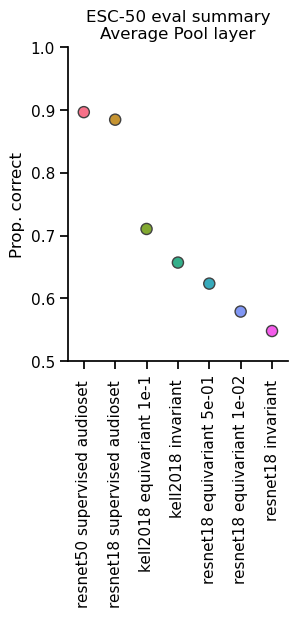

In [55]:

sns.set_context('notebook')
g = sns.catplot(data=df[df.test_layer=='avgpool'].sort_values("overall_acc", ascending=False), kind='swarm',
                y='overall_acc', ls='', x='model_name',
                size=8,
                height=4, aspect=1, 
                palette='husl')

g.set_xticklabels(rotation=90)
g.set(xlabel='', ylabel='Prop. correct', title='ESC-50 eval summary\nAverage Pool layer', ylim=(.5,1) )


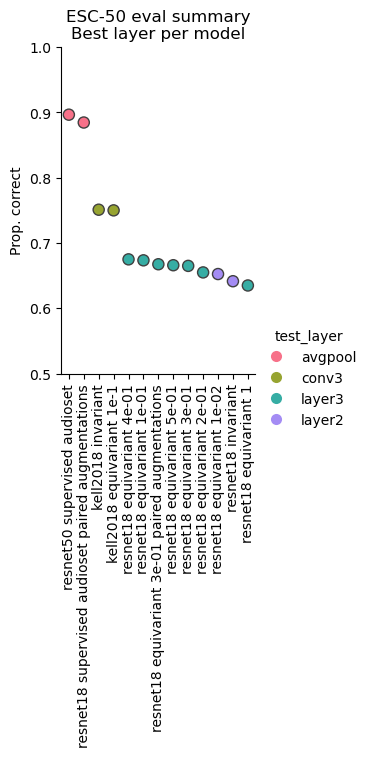

In [87]:
g = sns.catplot(data=df.sort_values('overall_acc', ascending=False).drop_duplicates('model_name'),
                kind='swarm',
                y='overall_acc', ls='', x='model_name',
                size=8,
                hue='test_layer',
                height=4, aspect=1, 
                palette='husl')
sns.set_context('notebook')

g.set_xticklabels(rotation=90)
g.set(xlabel='', ylabel='Prop. correct', title='ESC-50 eval summary\nBest layer per model', ylim=(.5,1) )